In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
import seaborn as sns
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix


In [2]:
raw_data=pd.read_csv('ai4i2020.csv')

In [3]:
raw_data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
raw_data.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00519,2.005923,294.0,298.30,300.1,301.50,304.9
Process temperature [K],10000.0,310.01461,1.493661,305.7,308.80,310.1,311.10,315.2
Rotational speed [rpm],10000.0,1539.39690,182.143317,1150.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.99097,10.000206,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.99650,63.724642,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [5]:
numeric_data=raw_data.drop(columns=['UDI','Product ID','Type','Machine failure','TWF','HDF','PWF','OSF','RNF'])

In [6]:
numeric_data.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,298.1,308.6,1551,42.8,0
1,298.2,308.7,1408,46.3,3
2,298.1,308.5,1498,49.4,5
3,298.2,308.6,1433,39.5,7
4,298.2,308.7,1408,40.0,9


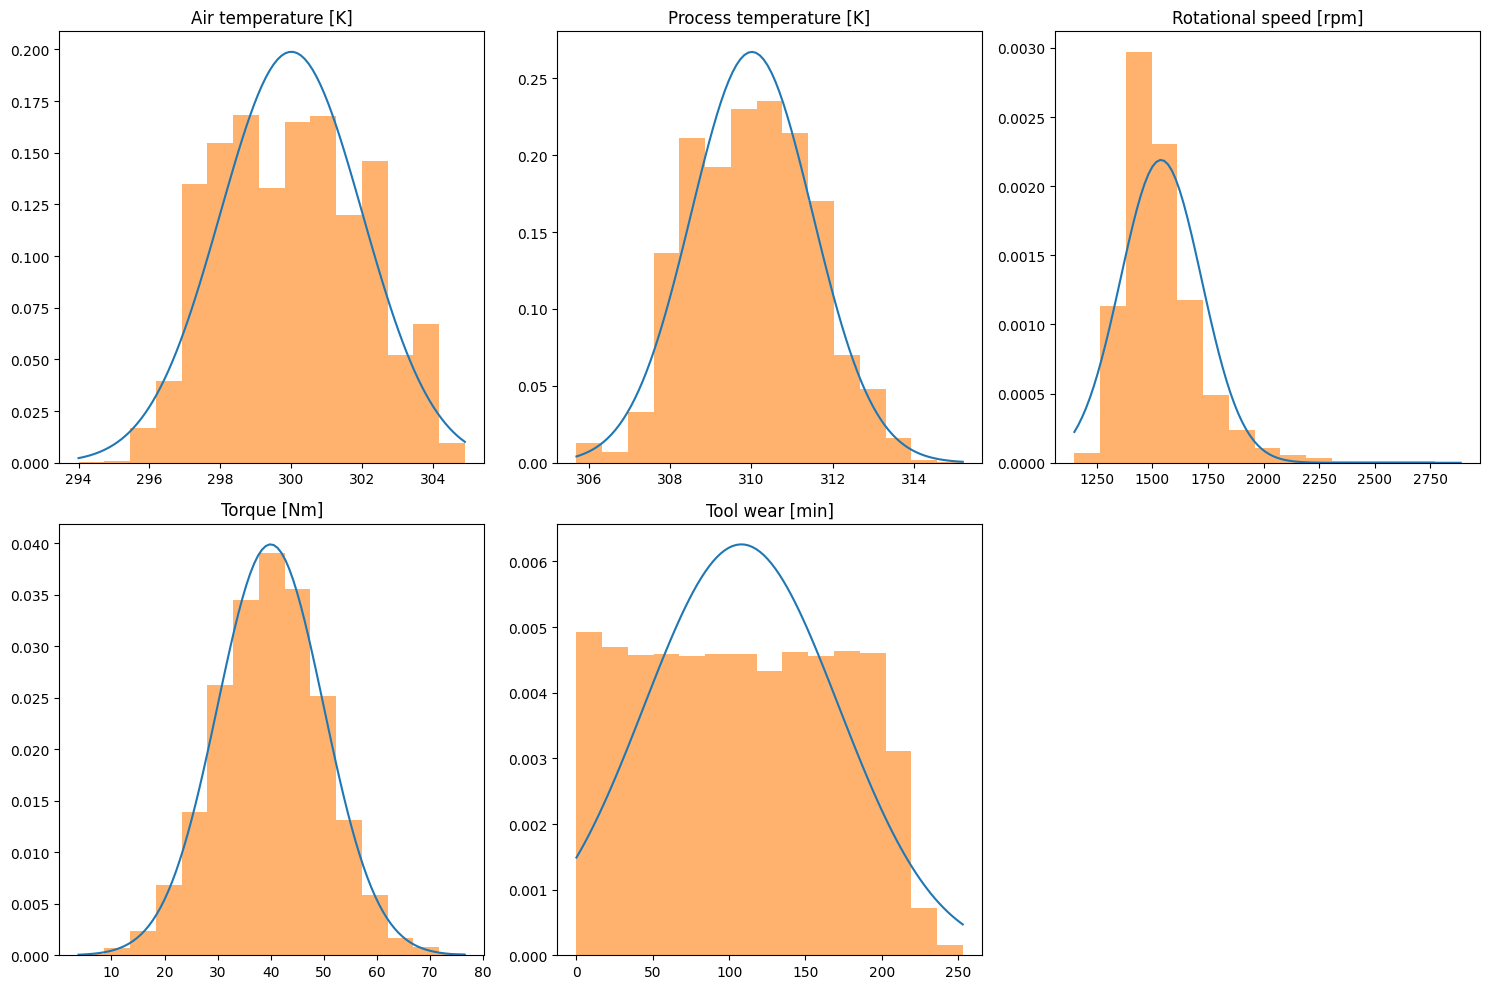

In [7]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

for i, (col, data) in enumerate(numeric_data.items()):
    # Calculate mean and standard deviation
    mu, std = np.mean(data), np.std(data)
    x = np.linspace(min(data), max(data), 100)
    # Plot normal curve
    ax = axs[i // 3, i % 3]
    ax.plot(x, norm.pdf(x, mu, std))
    ax.set_title(col)
    ax.hist(data, density=True, bins=15, alpha=0.6)

# Hide the empty subplot
axs[1, 2].axis('off')

plt.tight_layout()
plt.show()

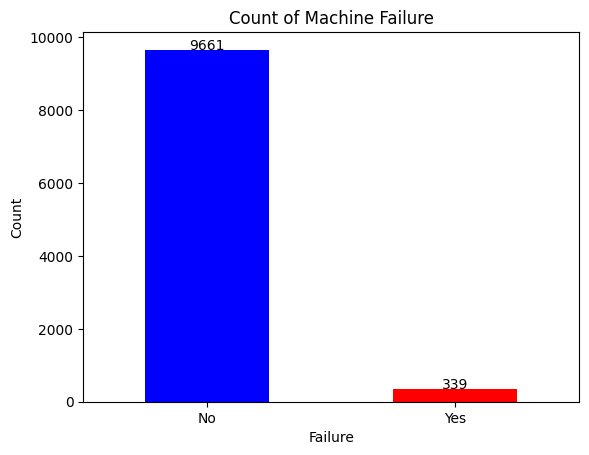

In [8]:
failure_counts = raw_data['Machine failure'].value_counts()



# Plotting
ax = failure_counts.plot(kind='bar', color=['blue', 'red'])

# Adding labels with exact counts
for i, count in enumerate(failure_counts):
    ax.text(i, count + 10, str(count), ha='center')

# Adding labels and title
plt.title('Count of Machine Failure')
plt.xlabel('Failure')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)

# Display the plot
plt.show()

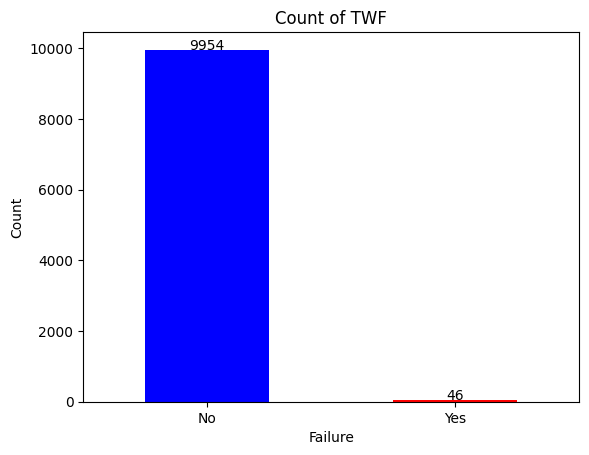

In [9]:
failure_counts = raw_data['TWF'].value_counts()



# Plotting
ax = failure_counts.plot(kind='bar', color=['blue', 'red'])

# Adding labels with exact counts
for i, count in enumerate(failure_counts):
    ax.text(i, count + 10, str(count), ha='center')

# Adding labels and title
plt.title('Count of TWF')
plt.xlabel('Failure')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)

# Display the plot
plt.show()

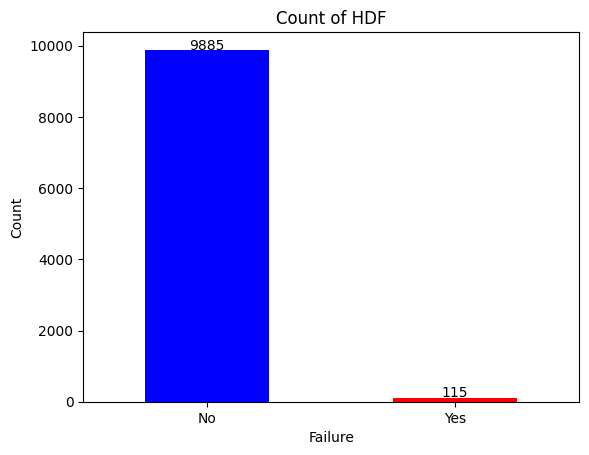

In [333]:
failure_counts = raw_data['HDF'].value_counts()



# Plotting
ax = failure_counts.plot(kind='bar', color=['blue', 'red'])

# Adding labels with exact counts
for i, count in enumerate(failure_counts):
    ax.text(i, count + 10, str(count), ha='center')

# Adding labels and title
plt.title('Count of HDF')
plt.xlabel('Failure')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)

# Display the plot
plt.show()

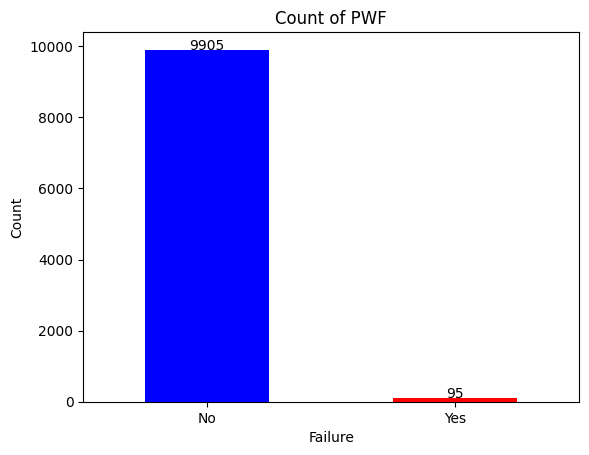

In [334]:
failure_counts = raw_data['PWF'].value_counts()



# Plotting
ax = failure_counts.plot(kind='bar', color=['blue', 'red'])

# Adding labels with exact counts
for i, count in enumerate(failure_counts):
    ax.text(i, count + 10, str(count), ha='center')

# Adding labels and title
plt.title('Count of PWF')
plt.xlabel('Failure')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)

# Display the plot
plt.show()

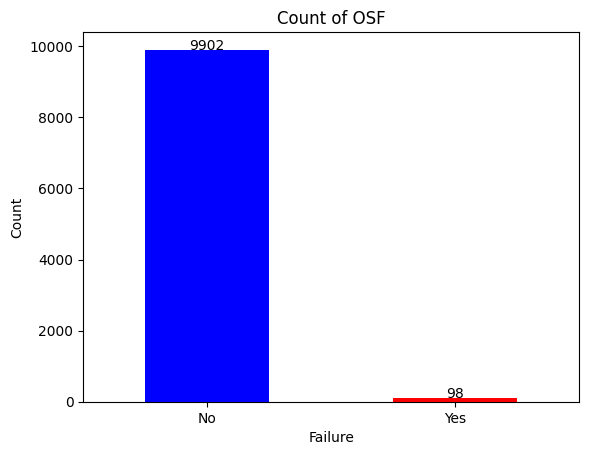

In [335]:
failure_counts = raw_data['OSF'].value_counts()



# Plotting
ax = failure_counts.plot(kind='bar', color=['blue', 'red'])

# Adding labels with exact counts
for i, count in enumerate(failure_counts):
    ax.text(i, count + 10, str(count), ha='center')

# Adding labels and title
plt.title('Count of OSF')
plt.xlabel('Failure')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)

# Display the plot
plt.show()

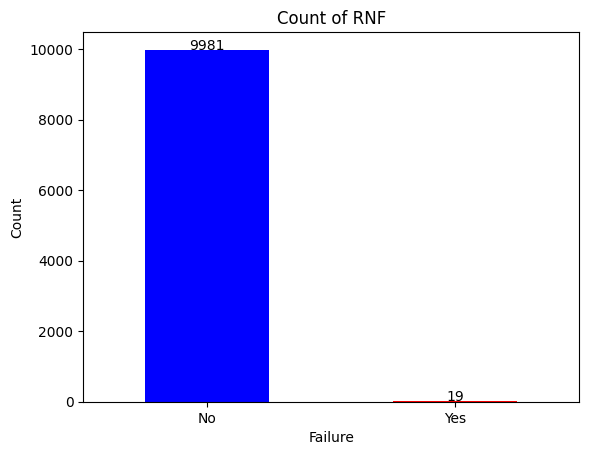

In [336]:
failure_counts = raw_data['RNF'].value_counts()



# Plotting
ax = failure_counts.plot(kind='bar', color=['blue', 'red'])

# Adding labels with exact counts
for i, count in enumerate(failure_counts):
    ax.text(i, count + 10, str(count), ha='center')

# Adding labels and title
plt.title('Count of RNF')
plt.xlabel('Failure')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)

# Display the plot
plt.show()

In [10]:
label_encoder = LabelEncoder()

# Encode the 'Type' column
raw_data['Type_encoded'] = label_encoder.fit_transform(raw_data['Type'])

# Display the first few rows of the dataset with the encoded column
print(raw_data.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  Type_encoded  
0    0    0    0    0             2  
1   

In [11]:
X=raw_data.drop(columns=['UDI', 'Product ID', 'Type','Machine failure','TWF','HDF','PWF','OSF','RNF'])
y=raw_data['Machine failure']

In [12]:
X

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_encoded
0,298.1,308.6,1551,42.8,0,2
1,298.2,308.7,1408,46.3,3,1
2,298.1,308.5,1498,49.4,5,1
3,298.2,308.6,1433,39.5,7,1
4,298.2,308.7,1408,40.0,9,1
...,...,...,...,...,...,...
9995,298.8,308.4,1604,29.5,14,2
9996,298.9,308.4,1632,31.8,17,0
9997,299.0,308.6,1645,33.4,22,2
9998,299.0,308.7,1408,48.5,25,0


In [13]:
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=25)

In [14]:
model1 = svm.SVC(C=10, degree=2)

# Fitting the model on the training data
model1.fit(X_train, y_train)

# Predicting on the testing data
y_pred = model1.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.97


In [15]:
model2 = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=5, min_samples_leaf=2, random_state=42)

# Fitting the model
model2.fit(X_train, y_train)

# Predicting without cross-validation
y_pred = model2.predict(X_test)

# You can then evaluate the predictions using metrics like accuracy_score, confusion_matrix, etc.
# For example:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9892


In [16]:
model3 = KNeighborsClassifier(n_neighbors=10)  # You can adjust the number of neighbors as needed

# Fitting the model
model3.fit(X_train, y_train)

# Predicting without cross-validation
y_pred_knn = model3.predict(X_test)

# Calculate accuracy for KNN
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.9728


In [17]:
model4 = LogisticRegression()

# Fitting the model
model4.fit(X_train, y_train)

# Predicting without cross-validation
y_pred_logistic = model4.predict(X_test)

# Calculate accuracy for Logistic Regression
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
print("Logistic Regression Accuracy:", accuracy_logistic)

Logistic Regression Accuracy: 0.9728


In [18]:
model5 = GradientBoostingClassifier()

# Fitting the model
model5.fit(X_train, y_train)

# Predicting without cross-validation
y_pred_gbm = model5.predict(X_test)

# Calculate accuracy for GBM
accuracy_gbm = accuracy_score(y_test, y_pred_gbm)
print("Gradient Boosting Accuracy:", accuracy_gbm)

Gradient Boosting Accuracy: 0.9908


# Individual Model and then assembling

In [19]:
co_df=raw_data.drop(columns=['UDI', 'Product ID', 'Type','TWF','HDF','PWF','OSF','RNF','Type_encoded'])


<Axes: >

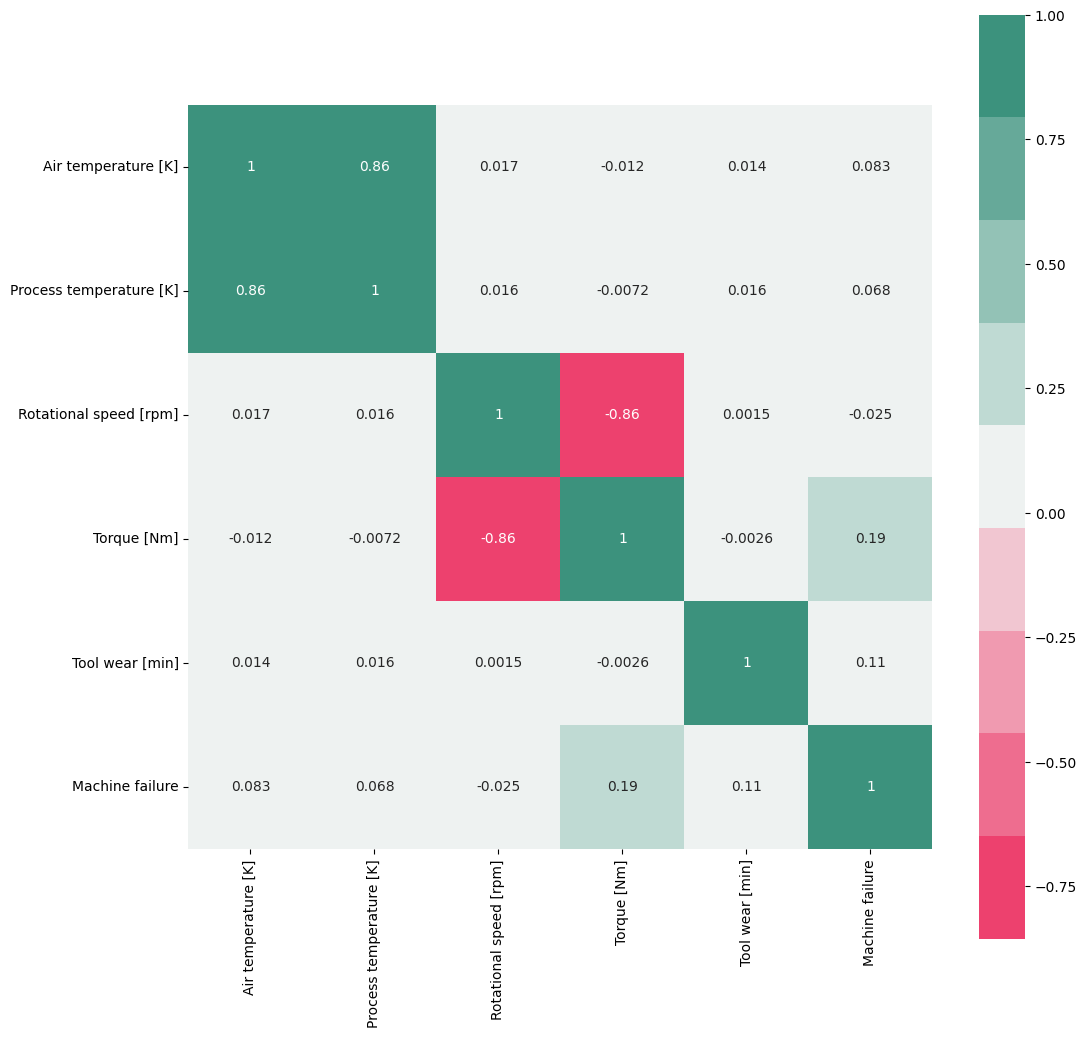

In [20]:
cmap = sns.diverging_palette(2, 165, s=80, l=55, n=9)
cdf=co_df
corrmat = cdf.corr()
plt.subplots(figsize=(12,12))
sns.heatmap(corrmat,cmap= cmap,annot=True, square=True)

# Feature Engineering

In [21]:
f_data=raw_data

In [22]:
f_data['RelationTemperature']=f_data['Air temperature [K]']-f_data['Process temperature [K]']
f_data['Power (W)'] = (f_data['Torque [Nm]'] * f_data['Rotational speed [rpm]']) / 9.5488
f_data['WearRPM'] = f_data['Tool wear [min]'] / f_data['Rotational speed [rpm]']
f_data['ToolWearTorque'] = f_data['Tool wear [min]'] / f_data['Torque [Nm]']

In [23]:
f_data.to_excel('data_after_FE.xlsx')

In [350]:
f_data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_encoded,RelationTemperature,Power (W),WearRPM,ToolWearTorque
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,2,-10.5,6951.952078,0.000000,0.000000
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,1,-10.5,6827.077748,0.002131,0.064795
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,1,-10.4,7749.790550,0.003338,0.101215
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,1,-10.4,5927.812919,0.004885,0.177215
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,1,-10.5,5898.123324,0.006392,0.225000


C:\Users\Proven\AppData\Local\Temp\ipykernel_13240\747091816.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corrmat = cdf.corr()


<Axes: >

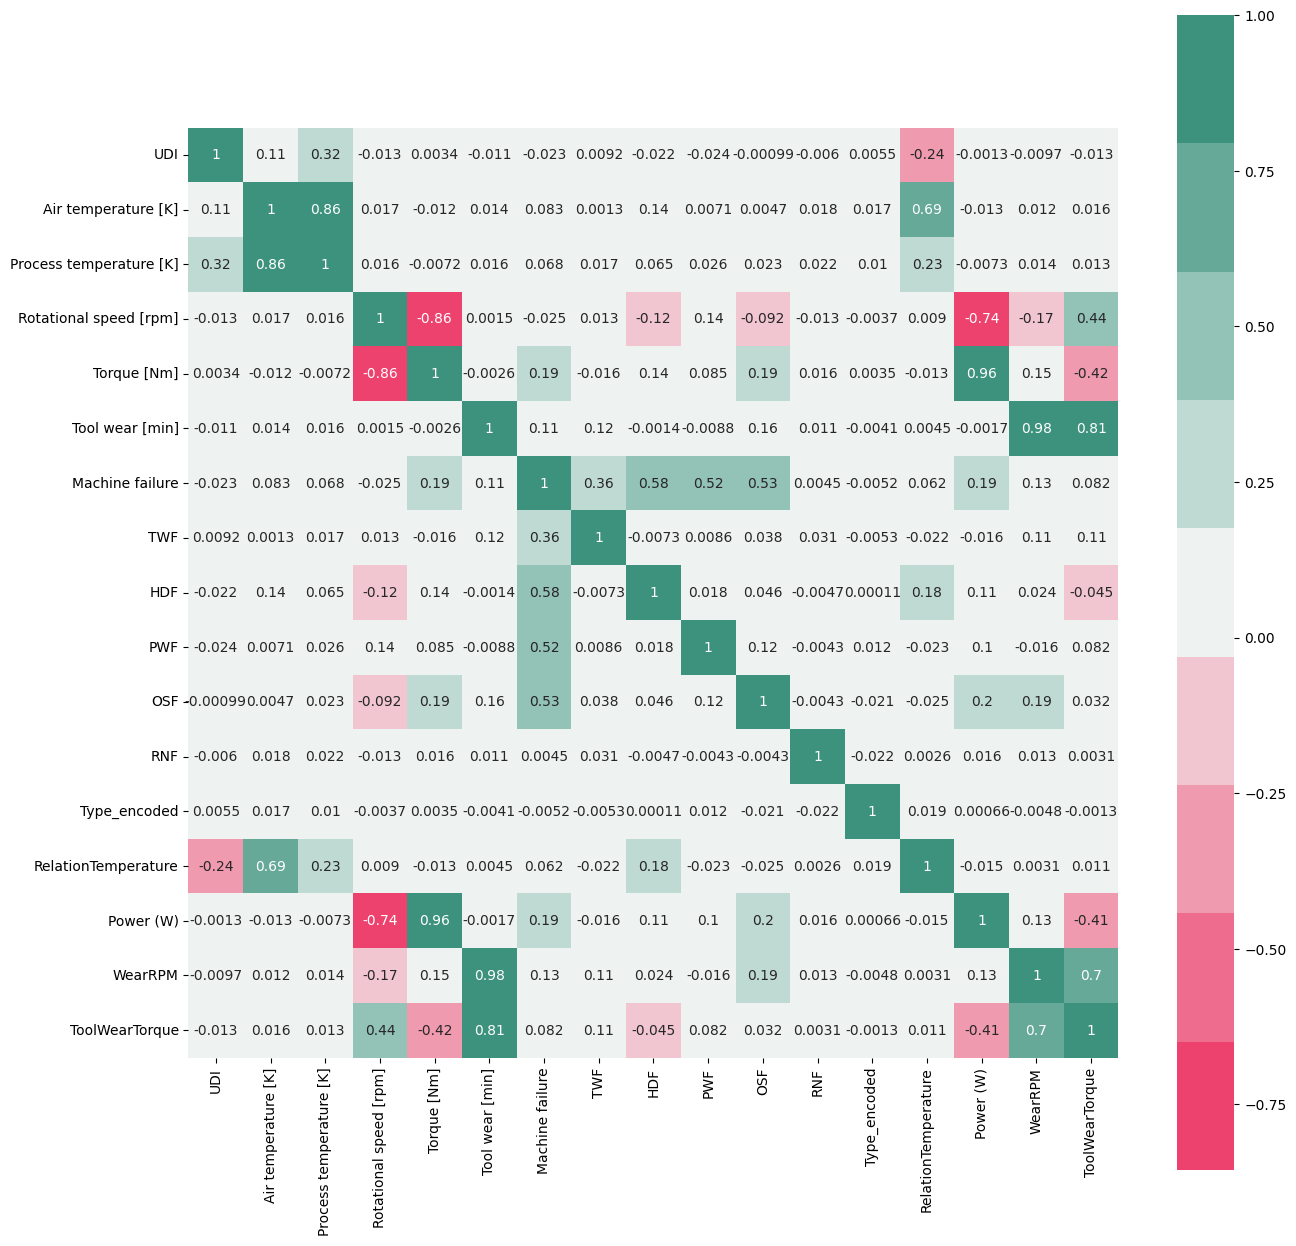

In [351]:
cmap = sns.diverging_palette(2, 165, s=80, l=55, n=9)
cdf=f_data
corrmat = cdf.corr()
plt.subplots(figsize=(15,15))
sns.heatmap(corrmat,cmap= cmap,annot=True, square=True)

In [352]:
X=f_data.drop(columns=['UDI', 'Product ID', 'Type','Machine failure','TWF','HDF','PWF','OSF','RNF'])
y=f_data['Machine failure']

In [353]:
X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_encoded,RelationTemperature,Power (W),WearRPM,ToolWearTorque
0,298.1,308.6,1551,42.8,0,2,-10.5,6951.952078,0.000000,0.000000
1,298.2,308.7,1408,46.3,3,1,-10.5,6827.077748,0.002131,0.064795
2,298.1,308.5,1498,49.4,5,1,-10.4,7749.790550,0.003338,0.101215
3,298.2,308.6,1433,39.5,7,1,-10.4,5927.812919,0.004885,0.177215
4,298.2,308.7,1408,40.0,9,1,-10.5,5898.123324,0.006392,0.225000


In [354]:
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=25)

In [25]:
model1 = svm.SVC(C=10, degree=2)

# Fitting the model on the training data
model1.fit(X_train, y_train)

# Predicting on the testing data
y_pred = model1.predict(X_test)
results_df = pd.DataFrame({'Real': y_test, 'SVM': y_pred})
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.97


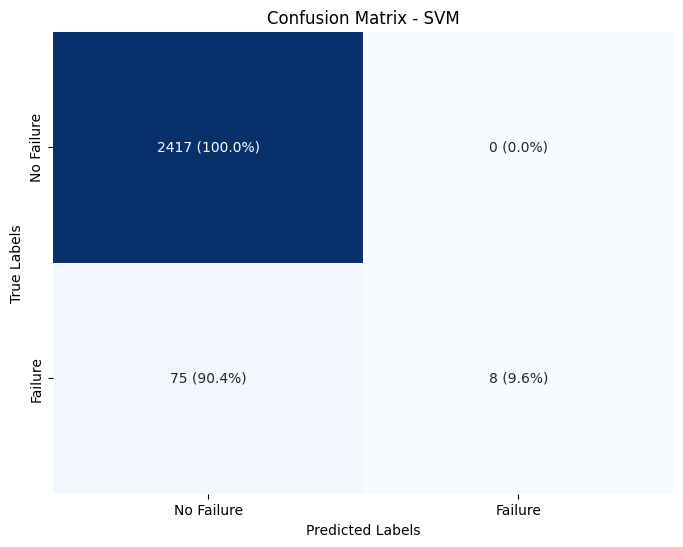

In [26]:
conf_mat = confusion_matrix(y_test, y_pred)

# Calculate percentages
conf_mat_percent = conf_mat / conf_mat.sum(axis=1)[:, np.newaxis] * 100

# Prepare annotations
annot_labels = [f'{conf_mat[i, j]} ({conf_mat_percent[i, j]:.1f}%)' for i in range(conf_mat.shape[0]) for j in range(conf_mat.shape[1])]
annot_labels = np.array(annot_labels).reshape(conf_mat.shape[0], conf_mat.shape[1])

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=annot_labels, fmt='', cmap='Blues', cbar=False, 
            xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - SVM')
plt.show()


In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
precision = precision_score(y_test, y_pred, average='weighted')
print("Precision:", precision)
recall = recall_score(y_test, y_pred, average='weighted')
print("Recall:", recall)
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1)

Precision: 0.9709028892455859
Recall: 0.97
F1 Score: 0.957866533547935


AUC-ROC: 0.8858188234942251


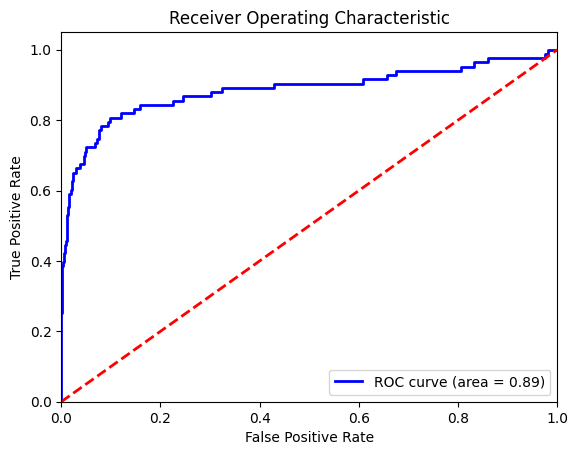

In [29]:
if len(set(y_test)) > 2:
    y_test_binarized = label_binarize(y_test, classes=list(set(y_test)))
    y_pred_binarized = label_binarize(y_pred, classes=list(set(y_pred)))
    auc = roc_auc_score(y_test_binarized, y_pred_binarized, average='weighted', multi_class='ovr')
else:
    y_score = model1.decision_function(X_test)
    auc = roc_auc_score(y_test, y_score)
print("AUC-ROC:", auc)

# Plotting the ROC curve (only works for binary classification)
if len(set(y_test)) == 2:
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % auc)
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

In [31]:
model2 = RandomForestClassifier(n_estimators=100,max_depth=15,min_samples_split=5,min_samples_leaf=2, random_state=42)  # You can adjust parameters like n_estimators, max_depth, etc.

# Fitting the model
model2.fit(X_train, y_train)
# Predicting on the testing data
y_pred = model2.predict(X_test)
results_df['RF'] = y_pred
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9892


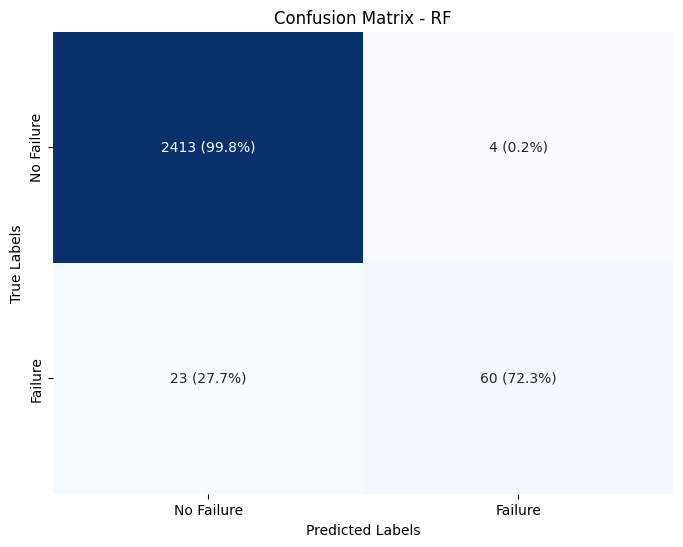

In [32]:
conf_mat = confusion_matrix(y_test, y_pred)

# Calculate percentages
conf_mat_percent = conf_mat / conf_mat.sum(axis=1)[:, np.newaxis] * 100

# Prepare annotations
annot_labels = [f'{conf_mat[i, j]} ({conf_mat_percent[i, j]:.1f}%)' for i in range(conf_mat.shape[0]) for j in range(conf_mat.shape[1])]
annot_labels = np.array(annot_labels).reshape(conf_mat.shape[0], conf_mat.shape[1])

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=annot_labels, fmt='', cmap='Blues', cbar=False, 
            xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - RF')
plt.show()


In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
precision = precision_score(y_test, y_pred, average='weighted')
print("Precision:", precision)
recall = recall_score(y_test, y_pred, average='weighted')
print("Recall:", recall)
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1)

Precision: 0.9887967569786535
Recall: 0.9892
F1 Score: 0.9885231823782471


AUC-ROC: 0.9916205990698417


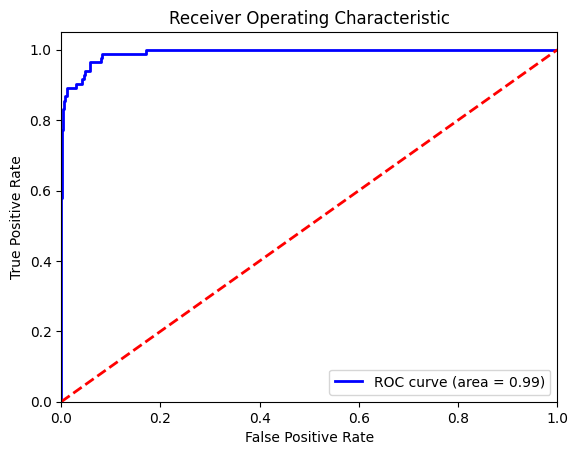

In [36]:
if len(set(y_test)) > 2:
    y_test_binarized = label_binarize(y_test, classes=list(set(y_test)))
    y_pred_binarized = label_binarize(y_pred, classes=list(set(y_pred)))
    auc = roc_auc_score(y_test_binarized, y_pred_binarized, average='weighted', multi_class='ovr')
else:
    # For RandomForestClassifier, use predict_proba instead of decision_function
    y_score = model2.predict_proba(X_test)[:, 1]  # Use probabilities of the positive class
    auc = roc_auc_score(y_test, y_score)
print("AUC-ROC:", auc)

# Plotting the ROC curve (only works for binary classification)
if len(set(y_test)) == 2:
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % auc)
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()


In [37]:
model3 = KNeighborsClassifier(n_neighbors=10)  # You can adjust the number of neighbors as needed

# Fitting the model
model3.fit(X_train, y_train)

# Predicting without cross-validation
y_pred = model3.predict(X_test)
results_df['KNN'] = y_pred
# Calculate accuracy for KNN
accuracy_knn = accuracy_score(y_test, y_pred)
print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.9728


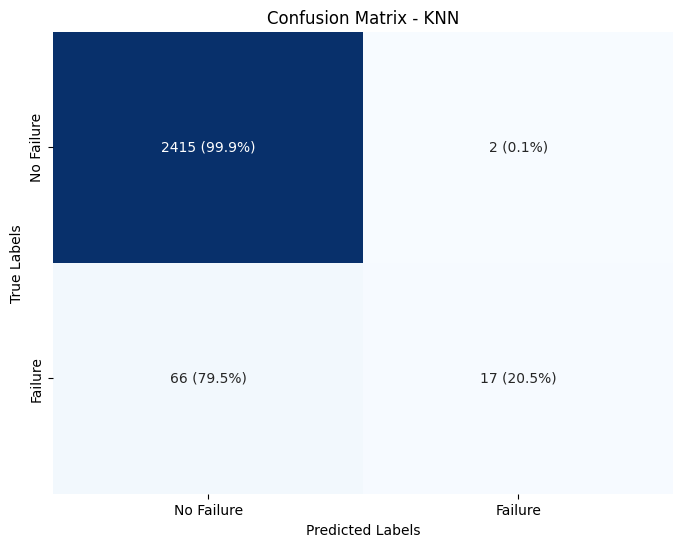

In [38]:
conf_mat = confusion_matrix(y_test, y_pred)

# Calculate percentages
conf_mat_percent = conf_mat / conf_mat.sum(axis=1)[:, np.newaxis] * 100

# Prepare annotations
annot_labels = [f'{conf_mat[i, j]} ({conf_mat_percent[i, j]:.1f}%)' for i in range(conf_mat.shape[0]) for j in range(conf_mat.shape[1])]
annot_labels = np.array(annot_labels).reshape(conf_mat.shape[0], conf_mat.shape[1])

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=annot_labels, fmt='', cmap='Blues', cbar=False, 
            xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - KNN')
plt.show()


In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
precision = precision_score(y_test, y_pred, average='weighted')
print("Precision:", precision)
recall = recall_score(y_test, y_pred, average='weighted')
print("Recall:", recall)
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1)

Precision: 0.9707862788773626
Recall: 0.9728
F1 Score: 0.9644443718524568


KNN AUC-ROC: 0.854521935487087


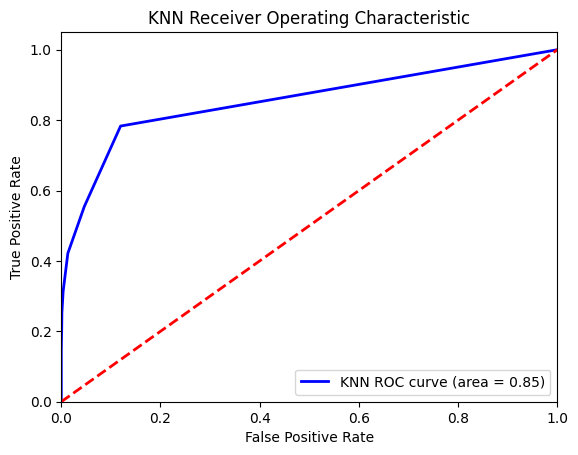

In [40]:
if len(set(y_test)) > 2:
    y_test_binarized = label_binarize(y_test, classes=list(set(y_test)))
    y_pred_binarized = label_binarize(y_pred, classes=list(set(y_pred)))
    auc_knn = roc_auc_score(y_test_binarized, y_pred_binarized, average='weighted', multi_class='ovr')
else:
    # For KNeighborsClassifier, use predict_proba instead of decision_function
    y_score_knn = model3.predict_proba(X_test)[:, 1]  # Use probabilities of the positive class
    auc_knn = roc_auc_score(y_test, y_score_knn)
print("KNN AUC-ROC:", auc_knn)

# Plotting the ROC curve (only works for binary classification)
if len(set(y_test)) == 2:
    fpr_knn, tpr_knn, _ = roc_curve(y_test, y_score_knn)
    plt.figure()
    plt.plot(fpr_knn, tpr_knn, color='blue', lw=2, label='KNN ROC curve (area = %0.2f)' % auc_knn)
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('KNN Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

In [41]:
model4 = LogisticRegression()

# Fitting the model
model4.fit(X_train, y_train)

# Predicting without cross-validation
y_pred = model4.predict(X_test)
results_df['LR'] = y_pred
# Calculate accuracy for Logistic Regression
accuracy_logistic = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", accuracy_logistic)

Logistic Regression Accuracy: 0.9728


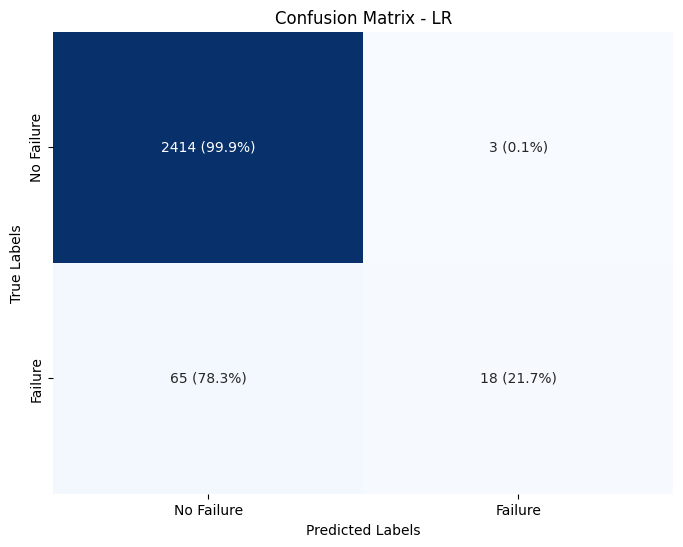

In [42]:
conf_mat = confusion_matrix(y_test, y_pred)

# Calculate percentages
conf_mat_percent = conf_mat / conf_mat.sum(axis=1)[:, np.newaxis] * 100

# Prepare annotations
annot_labels = [f'{conf_mat[i, j]} ({conf_mat_percent[i, j]:.1f}%)' for i in range(conf_mat.shape[0]) for j in range(conf_mat.shape[1])]
annot_labels = np.array(annot_labels).reshape(conf_mat.shape[0], conf_mat.shape[1])

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=annot_labels, fmt='', cmap='Blues', cbar=False, 
            xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - LR')
plt.show()


In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
precision = precision_score(y_test, y_pred, average='weighted')
print("Precision:", precision)
recall = recall_score(y_test, y_pred, average='weighted')
print("Recall:", recall)
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1)

Precision: 0.9699074050596439
Recall: 0.9728
F1 Score: 0.9648645299145299


Logistic Regression AUC-ROC: 0.8549830268529642


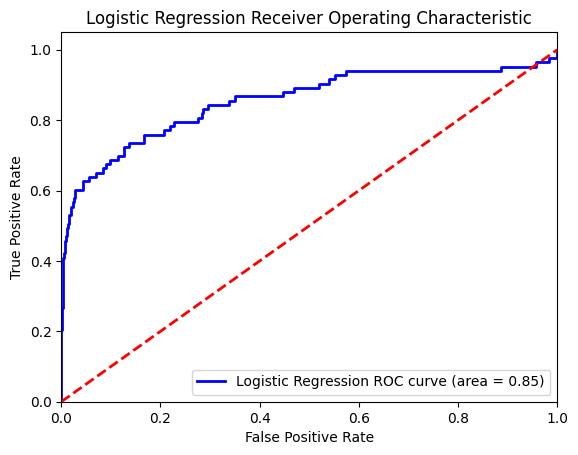

In [44]:
if len(set(y_test)) > 2:
    y_test_binarized = label_binarize(y_test, classes=list(set(y_test)))
    y_pred_binarized = label_binarize(y_pred, classes=list(set(y_pred)))
    auc_logistic = roc_auc_score(y_test_binarized, y_pred_binarized, average='weighted', multi_class='ovr')
else:
    # For LogisticRegression, use decision_function for AUC-ROC
    y_score_logistic = model4.decision_function(X_test)
    auc_logistic = roc_auc_score(y_test, y_score_logistic)
print("Logistic Regression AUC-ROC:", auc_logistic)

# Plotting the ROC curve (only works for binary classification)
if len(set(y_test)) == 2:
    fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_score_logistic)
    plt.figure()
    plt.plot(fpr_logistic, tpr_logistic, color='blue', lw=2, label='Logistic Regression ROC curve (area = %0.2f)' % auc_logistic)
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Logistic Regression Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

In [45]:
model5 = GradientBoostingClassifier()

# Fitting the model
model5.fit(X_train, y_train)

# Predicting without cross-validation
y_pred = model5.predict(X_test)

results_df['GBM'] = y_pred
# Calculate accuracy for GBM
accuracy_gbm = accuracy_score(y_test, y_pred)
print("Gradient Boosting Accuracy:", accuracy_gbm)

Gradient Boosting Accuracy: 0.9908


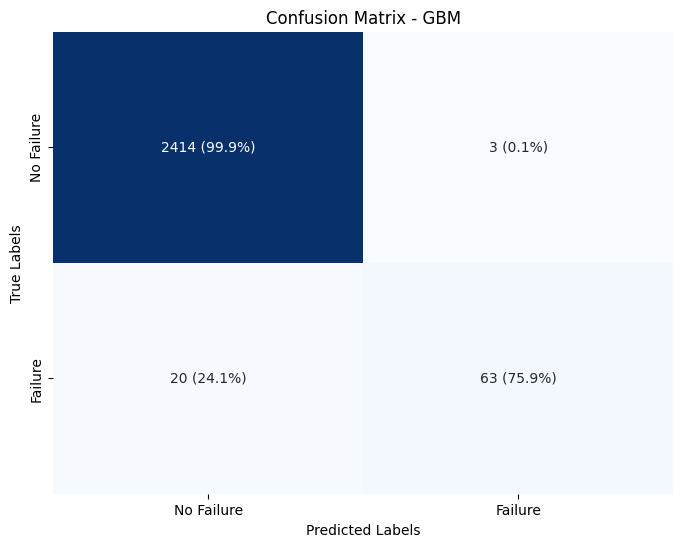

In [46]:
conf_mat = confusion_matrix(y_test, y_pred)

# Calculate percentages
conf_mat_percent = conf_mat / conf_mat.sum(axis=1)[:, np.newaxis] * 100

# Prepare annotations
annot_labels = [f'{conf_mat[i, j]} ({conf_mat_percent[i, j]:.1f}%)' for i in range(conf_mat.shape[0]) for j in range(conf_mat.shape[1])]
annot_labels = np.array(annot_labels).reshape(conf_mat.shape[0], conf_mat.shape[1])

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=annot_labels, fmt='', cmap='Blues', cbar=False, 
            xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - GBM')
plt.show()

In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
precision = precision_score(y_test, y_pred, average='weighted')
print("Precision:", precision)
recall = recall_score(y_test, y_pred, average='weighted')
print("Recall:", recall)
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1)

Precision: 0.9905467841936206
Recall: 0.9908
F1 Score: 0.990291288172784


Gradient Boosting AUC-ROC: 0.9882508935202955


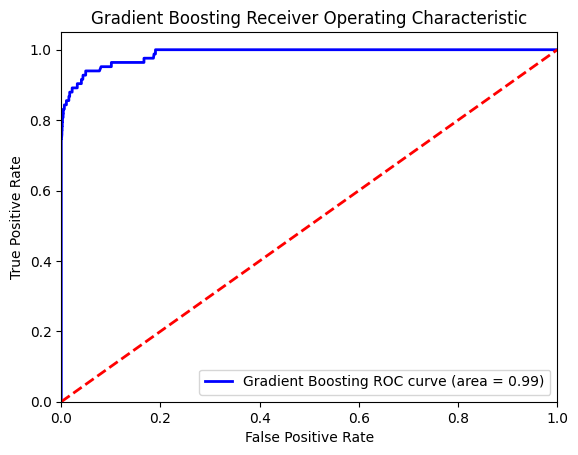

In [48]:
if len(set(y_test)) > 2:
    y_test_binarized = label_binarize(y_test, classes=list(set(y_test)))
    y_pred_binarized = label_binarize(y_pred, classes=list(set(y_pred)))
    auc_gbm = roc_auc_score(y_test_binarized, y_pred_binarized, average='weighted', multi_class='ovr')
else:
    # For GradientBoostingClassifier, use decision_function for AUC-ROC
    y_score_gbm = model5.decision_function(X_test)
    auc_gbm = roc_auc_score(y_test, y_score_gbm)
print("Gradient Boosting AUC-ROC:", auc_gbm)

# Plotting the ROC curve (only works for binary classification)
if len(set(y_test)) == 2:
    fpr_gbm, tpr_gbm, _ = roc_curve(y_test, y_score_gbm)
    plt.figure()
    plt.plot(fpr_gbm, tpr_gbm, color='blue', lw=2, label='Gradient Boosting ROC curve (area = %0.2f)' % auc_gbm)
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Gradient Boosting Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

In [365]:
# Define the ensemble classifier
ensemble_clf = VotingClassifier(estimators=[
    ('svm', model1),
    ('random_forest', model2),
    ('knn', model3),
    ('logistic_regression', model4),
    ('gradient_boosting', model5)
], voting='hard')  # Use 'hard' voting for classification

# Fit the ensemble classifier on the training data
ensemble_clf.fit(X_train, y_train)

# Predict on the testing data using the ensemble classifier
y_pred = ensemble_clf.predict(X_test)

# Calculate accuracy for the ensemble classifier
accuracy_ensemble = accuracy_score(y_test, y_pred)
print("Ensemble Accuracy:", accuracy_ensemble)


C:\Users\Proven\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Ensemble Accuracy: 0.9816


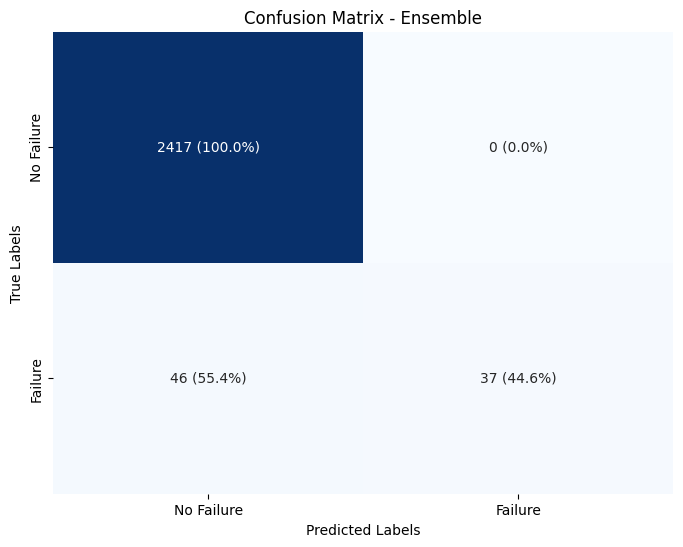

In [366]:
conf_mat = confusion_matrix(y_test, y_pred)

# Calculate percentages
conf_mat_percent = conf_mat / conf_mat.sum(axis=1)[:, np.newaxis] * 100

# Prepare annotations
annot_labels = [f'{conf_mat[i, j]} ({conf_mat_percent[i, j]:.1f}%)' for i in range(conf_mat.shape[0]) for j in range(conf_mat.shape[1])]
annot_labels = np.array(annot_labels).reshape(conf_mat.shape[0], conf_mat.shape[1])

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=annot_labels, fmt='', cmap='Blues', cbar=False, 
            xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Ensemble')
plt.show()

In [367]:
results_df.to_excel('results.xlsx')

In [368]:
sum_excluding_real=results_df.drop('Real', axis=1).sum(axis=1)
results_df['sum_excluding_real'] = (sum_excluding_real > 0).astype(int)

In [369]:
results_df.to_excel('results.xlsx')

In [370]:
f_a = accuracy_score(results_df['Real'], results_df['sum_excluding_real'])
print("Accuracy:", f_a)

Accuracy: 0.9916


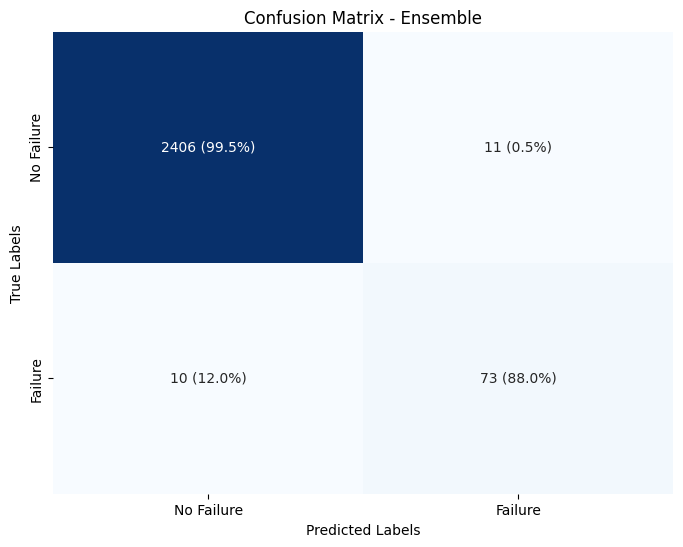

In [371]:
y_test=results_df['Real']
y_pred=results_df['sum_excluding_real']
conf_mat = confusion_matrix(y_test, y_pred)

# Calculate percentages
conf_mat_percent = conf_mat / conf_mat.sum(axis=1)[:, np.newaxis] * 100

# Prepare annotations
annot_labels = [f'{conf_mat[i, j]} ({conf_mat_percent[i, j]:.1f}%)' for i in range(conf_mat.shape[0]) for j in range(conf_mat.shape[1])]
annot_labels = np.array(annot_labels).reshape(conf_mat.shape[0], conf_mat.shape[1])

# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=annot_labels, fmt='', cmap='Blues', cbar=False, 
            xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Ensemble')
plt.show()

In [372]:
air_temp=0.083
process_temp=0.068
speed=0.025
torque=0.19
wear=0.11
r_temp=0.062
power=0.19
wear_rpm=0.13
tw_torque=0.082

total_sum = air_temp + process_temp + speed + torque + wear + r_temp + power + wear_rpm + tw_torque

# Normalize the values
air_temp_normalized = air_temp / total_sum
process_temp_normalized = process_temp / total_sum
speed_normalized = speed / total_sum
torque_normalized = torque / total_sum
wear_normalized = wear / total_sum
r_temp_normalized = r_temp / total_sum
power_normalized = power / total_sum
wear_rpm_normalized = wear_rpm / total_sum
tw_torque_normalized = tw_torque / total_sum

In [373]:
print("Normalized air_temp:", air_temp_normalized)
print("Normalized process_temp:", process_temp_normalized)
print("Normalized speed:", speed_normalized)
print("Normalized torque:", torque_normalized)
print("Normalized wear:", wear_normalized)
print("Normalized r_temp:", r_temp_normalized)
print("Normalized power:", power_normalized)
print("Normalized wear_rpm:", wear_rpm_normalized)
print("Normalized tw_torque:", tw_torque_normalized)

Normalized air_temp: 0.08829787234042555
Normalized process_temp: 0.0723404255319149
Normalized speed: 0.026595744680851068
Normalized torque: 0.2021276595744681
Normalized wear: 0.11702127659574468
Normalized r_temp: 0.06595744680851064
Normalized power: 0.2021276595744681
Normalized wear_rpm: 0.13829787234042554
Normalized tw_torque: 0.0872340425531915


In [374]:
f_data['risk factor']=f_data['Air temperature [K]']*air_temp_normalized+f_data['Process temperature [K]']*process_temp_normalized-f_data['Rotational speed [rpm]']*speed_normalized+f_data['Torque [Nm]']*torque_normalized+f_data['Tool wear [min]']*wear_normalized+f_data['RelationTemperature']*r_temp_normalized+f_data['Power (W)']*power_normalized+f_data['WearRPM']*wear_rpm_normalized+f_data['ToolWearTorque']*tw_torque_normalized

In [375]:
f_data

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_encoded,RelationTemperature,Power (W),WearRPM,ToolWearTorque,risk factor
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,2,-10.5,6951.952078,0.000000,0.000000,1420.536165
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,1,-10.5,6827.077748,0.002131,0.064795,1400.179322
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,1,-10.4,7749.790550,0.003338,0.101215,1585.138764
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,1,-10.4,5927.812919,0.004885,0.177215,1216.851299
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,1,-10.5,5898.123324,0.006392,0.225000,1211.855226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,2,-9.6,4955.387064,0.008728,0.474576,1014.664885
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0,0,-9.5,5434.986595,0.010417,0.534591,1111.697387
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,2,-9.6,5753.916723,0.013374,0.658683,1176.752689
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0,0,-9.7,7151.474531,0.017756,0.515464,1468.932912


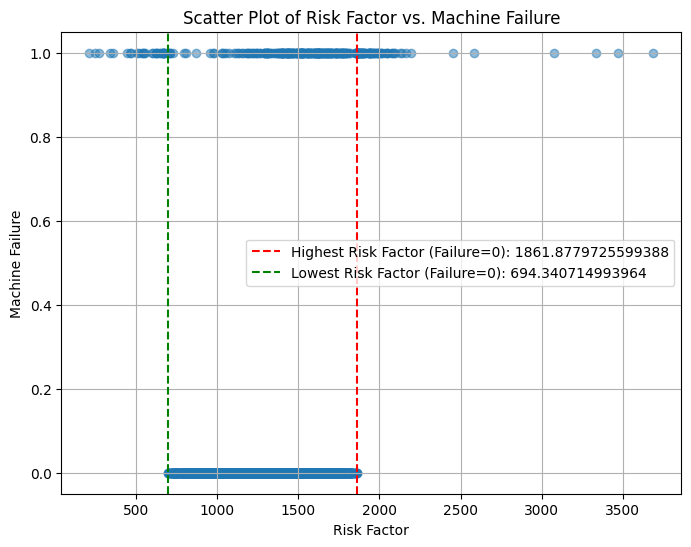

In [376]:
filtered_data = f_data[f_data['Machine failure'] == 0]

# Find the maximum and minimum Risk Factor where Machine Failure is 0
max_risk_factor_failure_0 = filtered_data['risk factor'].max()
min_risk_factor_failure_0 = filtered_data['risk factor'].min()

# Plot scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(f_data['risk factor'], f_data['Machine failure'], alpha=0.5)
plt.axvline(x=max_risk_factor_failure_0, color='red', linestyle='--', label=f'Highest Risk Factor (Failure=0): {max_risk_factor_failure_0}')
plt.axvline(x=min_risk_factor_failure_0, color='green', linestyle='--', label=f'Lowest Risk Factor (Failure=0): {min_risk_factor_failure_0}')
plt.title('Scatter Plot of Risk Factor vs. Machine Failure')
plt.xlabel('Risk Factor')
plt.ylabel('Machine Failure')
plt.grid(True)
plt.legend()
plt.show()

# 2nd Phase

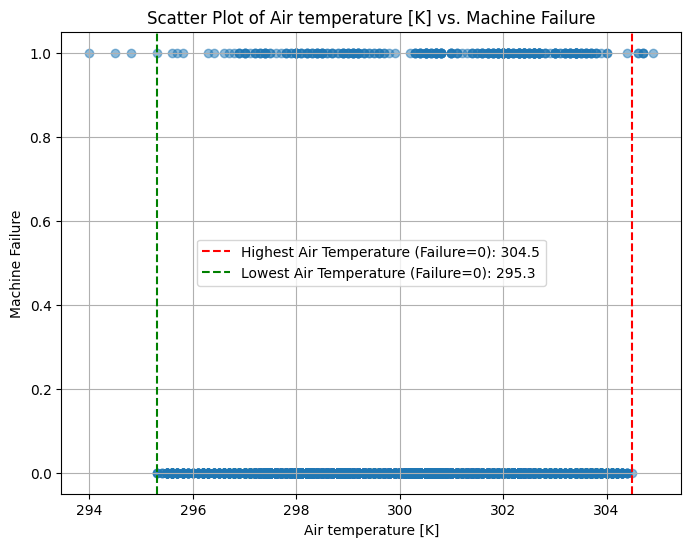

In [377]:
import matplotlib.pyplot as plt

# Filter the data where Machine Failure is 0
filtered_data = f_data[f_data['Machine failure'] == 0]

# Find the maximum and minimum Air temperature [K] where Machine Failure is 0
max_air_temp_failure_0 = filtered_data['Air temperature [K]'].max()
min_air_temp_failure_0 = filtered_data['Air temperature [K]'].min()

# Plot scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(f_data['Air temperature [K]'], f_data['Machine failure'], alpha=0.5)
plt.axvline(x=max_air_temp_failure_0, color='red', linestyle='--', label=f'Highest Air Temperature (Failure=0): {max_air_temp_failure_0}')
plt.axvline(x=min_air_temp_failure_0, color='green', linestyle='--', label=f'Lowest Air Temperature (Failure=0): {min_air_temp_failure_0}')
plt.title('Scatter Plot of Air temperature [K] vs. Machine Failure')
plt.xlabel('Air temperature [K]')
plt.ylabel('Machine Failure')
plt.grid(True)
plt.legend()
plt.show()


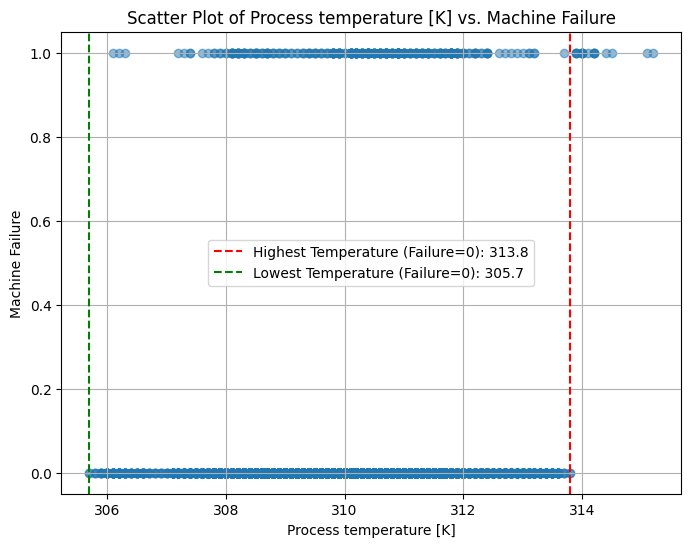

In [378]:
filtered_data = f_data[f_data['Machine failure'] == 0]

# Find the maximum and minimum Process temperature [K] where Machine Failure is 0
max_temp_failure_0 = filtered_data['Process temperature [K]'].max()
min_temp_failure_0 = filtered_data['Process temperature [K]'].min()

# Plot scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(f_data['Process temperature [K]'], f_data['Machine failure'], alpha=0.5)
plt.axvline(x=max_temp_failure_0, color='red', linestyle='--', label=f'Highest Temperature (Failure=0): {max_temp_failure_0}')
plt.axvline(x=min_temp_failure_0, color='green', linestyle='--', label=f'Lowest Temperature (Failure=0): {min_temp_failure_0}')
plt.title('Scatter Plot of Process temperature [K] vs. Machine Failure')
plt.xlabel('Process temperature [K]')
plt.ylabel('Machine Failure')
plt.grid(True)
plt.legend()
plt.show()

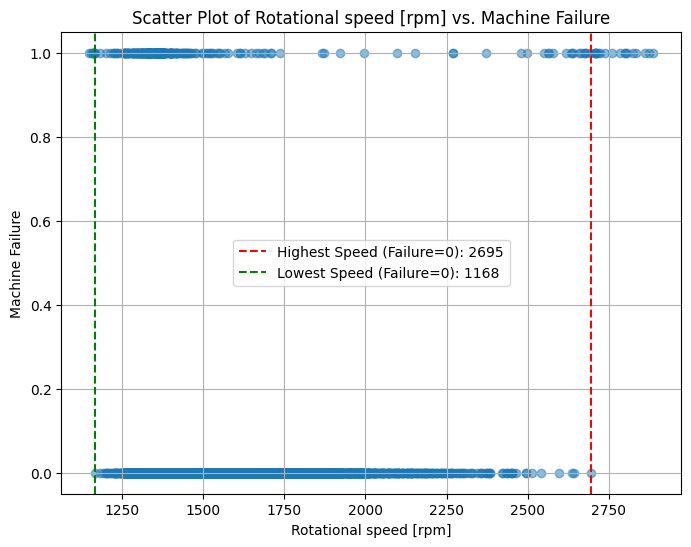

In [379]:
filtered_data = f_data[f_data['Machine failure'] == 0]

# Find the maximum and minimum Rotational speed [rpm] where Machine Failure is 0
max_speed_failure_0 = filtered_data['Rotational speed [rpm]'].max()
min_speed_failure_0 = filtered_data['Rotational speed [rpm]'].min()

# Plot scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(f_data['Rotational speed [rpm]'], f_data['Machine failure'], alpha=0.5)
plt.axvline(x=max_speed_failure_0, color='red', linestyle='--', label=f'Highest Speed (Failure=0): {max_speed_failure_0}')
plt.axvline(x=min_speed_failure_0, color='green', linestyle='--', label=f'Lowest Speed (Failure=0): {min_speed_failure_0}')
plt.title('Scatter Plot of Rotational speed [rpm] vs. Machine Failure')
plt.xlabel('Rotational speed [rpm]')
plt.ylabel('Machine Failure')
plt.grid(True)
plt.legend()
plt.show()


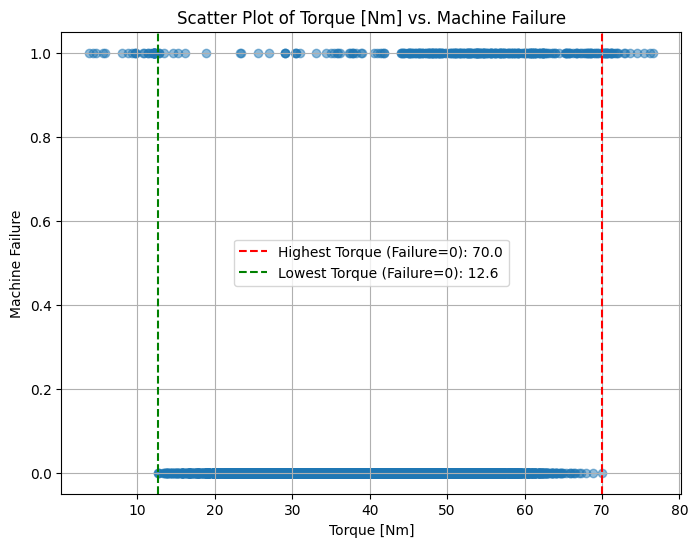

In [380]:
filtered_data = f_data[f_data['Machine failure'] == 0]

# Find the maximum and minimum Torque [Nm] where Machine Failure is 0
max_torque_failure_0 = filtered_data['Torque [Nm]'].max()
min_torque_failure_0 = filtered_data['Torque [Nm]'].min()

# Plot scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(f_data['Torque [Nm]'], f_data['Machine failure'], alpha=0.5)
plt.axvline(x=max_torque_failure_0, color='red', linestyle='--', label=f'Highest Torque (Failure=0): {max_torque_failure_0}')
plt.axvline(x=min_torque_failure_0, color='green', linestyle='--', label=f'Lowest Torque (Failure=0): {min_torque_failure_0}')
plt.title('Scatter Plot of Torque [Nm] vs. Machine Failure')
plt.xlabel('Torque [Nm]')
plt.ylabel('Machine Failure')
plt.grid(True)
plt.legend()
plt.show()

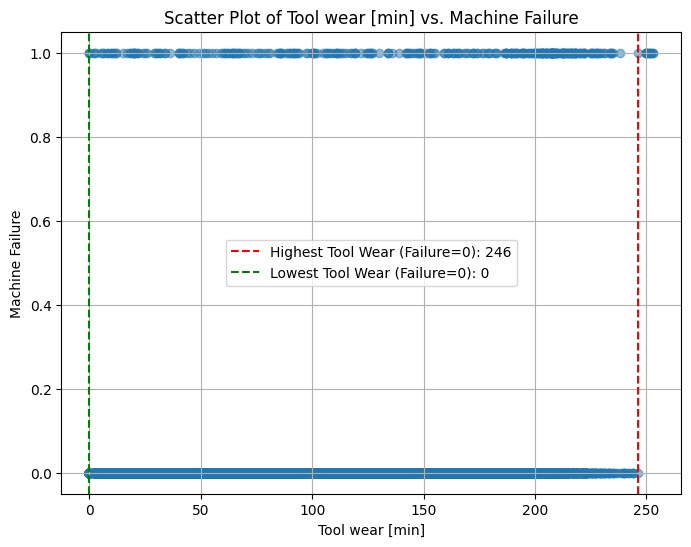

In [381]:

filtered_data = f_data[f_data['Machine failure'] == 0]

# Find the maximum and minimum Tool wear [min] where Machine Failure is 0
max_tool_wear_failure_0 = filtered_data['Tool wear [min]'].max()
min_tool_wear_failure_0 = filtered_data['Tool wear [min]'].min()

# Plot scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(f_data['Tool wear [min]'], f_data['Machine failure'], alpha=0.5)
plt.axvline(x=max_tool_wear_failure_0, color='red', linestyle='--', label=f'Highest Tool Wear (Failure=0): {max_tool_wear_failure_0}')
plt.axvline(x=min_tool_wear_failure_0, color='green', linestyle='--', label=f'Lowest Tool Wear (Failure=0): {min_tool_wear_failure_0}')
plt.title('Scatter Plot of Tool wear [min] vs. Machine Failure')
plt.xlabel('Tool wear [min]')
plt.ylabel('Machine Failure')
plt.grid(True)
plt.legend()
plt.show()


9661


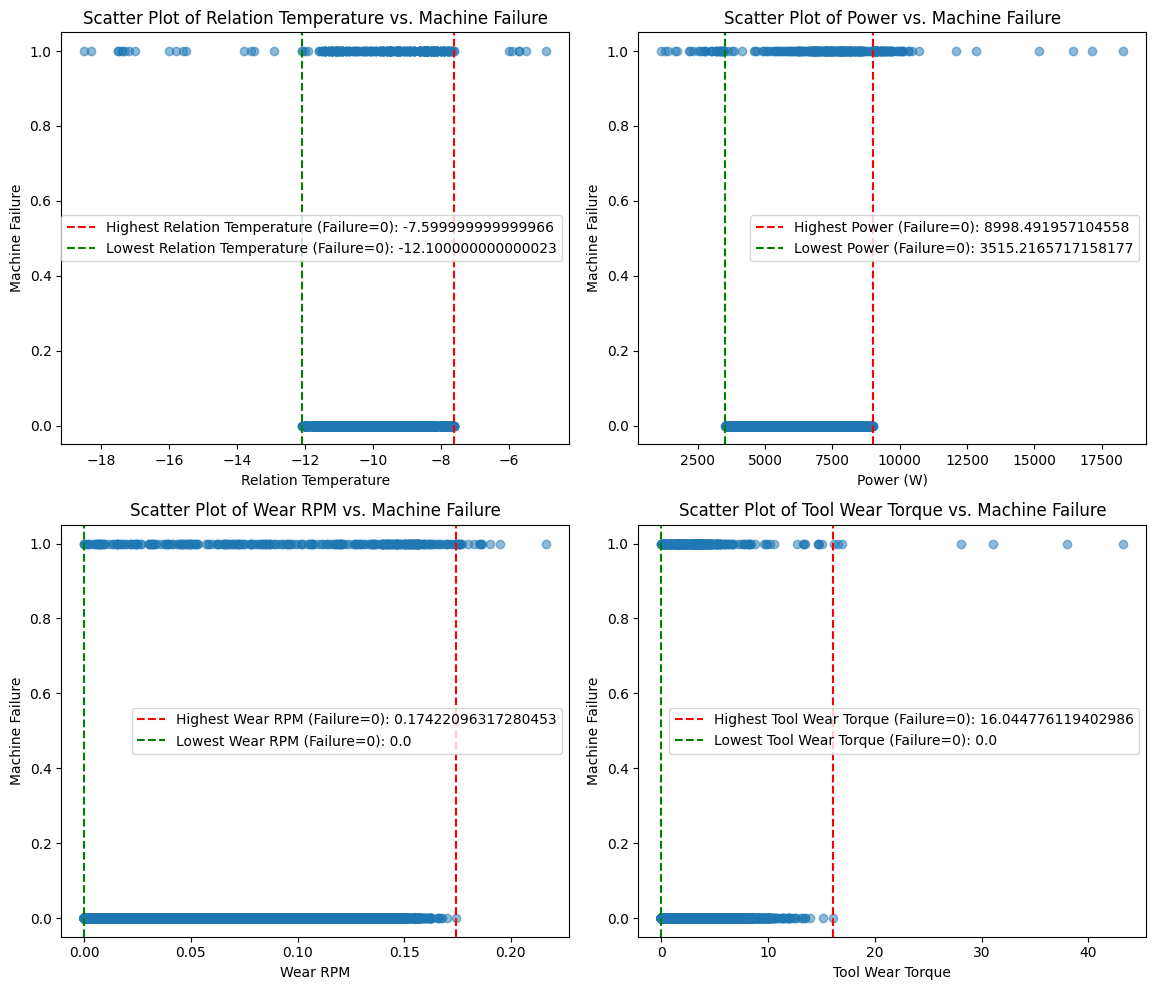

In [382]:
import matplotlib.pyplot as plt

# Filter the data where Machine Failure is 0
filtered_data = f_data[f_data['Machine failure'] == 0]
print(len(filtered_data))
# Find the maximum and minimum values for each feature where Machine Failure is 0
max_relation_temp_failure_0 = filtered_data['RelationTemperature'].max()
min_relation_temp_failure_0 = filtered_data['RelationTemperature'].min()

max_power_failure_0 = filtered_data['Power (W)'].max()
min_power_failure_0 = filtered_data['Power (W)'].min()

max_wear_rpm_failure_0 = filtered_data['WearRPM'].max()
min_wear_rpm_failure_0 = filtered_data['WearRPM'].min()

max_tool_wear_torque_failure_0 = filtered_data['ToolWearTorque'].max()
min_tool_wear_torque_failure_0 = filtered_data['ToolWearTorque'].min()

# Plot scatter plots with vertical lines
plt.figure(figsize=(12, 10))

# RelationTemperature
plt.subplot(221)
plt.scatter(f_data['RelationTemperature'], f_data['Machine failure'], alpha=0.5)
plt.axvline(x=max_relation_temp_failure_0, color='red', linestyle='--', label=f'Highest Relation Temperature (Failure=0): {max_relation_temp_failure_0}')
plt.axvline(x=min_relation_temp_failure_0, color='green', linestyle='--', label=f'Lowest Relation Temperature (Failure=0): {min_relation_temp_failure_0}')
plt.title('Scatter Plot of Relation Temperature vs. Machine Failure')
plt.xlabel('Relation Temperature')
plt.ylabel('Machine Failure')
plt.legend()

# Power (W)
plt.subplot(222)
plt.scatter(f_data['Power (W)'], f_data['Machine failure'], alpha=0.5)
plt.axvline(x=max_power_failure_0, color='red', linestyle='--', label=f'Highest Power (Failure=0): {max_power_failure_0}')
plt.axvline(x=min_power_failure_0, color='green', linestyle='--', label=f'Lowest Power (Failure=0): {min_power_failure_0}')
plt.title('Scatter Plot of Power vs. Machine Failure')
plt.xlabel('Power (W)')
plt.ylabel('Machine Failure')
plt.legend()

# WearRPM
plt.subplot(223)
plt.scatter(f_data['WearRPM'], f_data['Machine failure'], alpha=0.5)
plt.axvline(x=max_wear_rpm_failure_0, color='red', linestyle='--', label=f'Highest Wear RPM (Failure=0): {max_wear_rpm_failure_0}')
plt.axvline(x=min_wear_rpm_failure_0, color='green', linestyle='--', label=f'Lowest Wear RPM (Failure=0): {min_wear_rpm_failure_0}')
plt.title('Scatter Plot of Wear RPM vs. Machine Failure')
plt.xlabel('Wear RPM')
plt.ylabel('Machine Failure')
plt.legend()

# ToolWearTorque
plt.subplot(224)
plt.scatter(f_data['ToolWearTorque'], f_data['Machine failure'], alpha=0.5)
plt.axvline(x=max_tool_wear_torque_failure_0, color='red', linestyle='--', label=f'Highest Tool Wear Torque (Failure=0): {max_tool_wear_torque_failure_0}')
plt.axvline(x=min_tool_wear_torque_failure_0, color='green', linestyle='--', label=f'Lowest Tool Wear Torque (Failure=0): {min_tool_wear_torque_failure_0}')
plt.title('Scatter Plot of Tool Wear Torque vs. Machine Failure')
plt.xlabel('Tool Wear Torque')
plt.ylabel('Machine Failure')
plt.legend()

plt.tight_layout()
plt.show()


In [383]:
# Filter the data where Machine failure is 0
failure_0_data = f_data[f_data['Machine failure'] == 0]

# Find the maximum and minimum values of the specified columns where Machine failure is 0
max_values_failure_0 = {
    'ToolWearTorque': failure_0_data['ToolWearTorque'].max(),
    'WearRPM': failure_0_data['WearRPM'].max(),
    'Power (W)': failure_0_data['Power (W)'].max(),
    'Torque [Nm]': failure_0_data['Torque [Nm]'].max(),
    'Tool wear [min]': failure_0_data['Tool wear [min]'].max(),
    'Rotational speed [rpm]': failure_0_data['Rotational speed [rpm]'].max(),
    'risk factor': failure_0_data['risk factor'].max()
}

min_values_failure_0 = {
    'ToolWearTorque': failure_0_data['ToolWearTorque'].min(),
    'WearRPM': failure_0_data['WearRPM'].min(),
    'Power (W)': failure_0_data['Power (W)'].min(),
    'Torque [Nm]': failure_0_data['Torque [Nm]'].min(),
    'Tool wear [min]': failure_0_data['Tool wear [min]'].min(),
    'Rotational speed [rpm]': failure_0_data['Rotational speed [rpm]'].min(),
    'risk factor': failure_0_data['risk factor'].min()
}

# Create new columns to indicate the conditions
f_data['ColumnFailure0'] = 0


# Update the new columns to 1 where any of the specified columns reaches its maximum or minimum value when Machine failure is 0
for column, max_value_failure_0 in max_values_failure_0.items():
    f_data.loc[(f_data[column] > max_value_failure_0), 'ColumnFailure0'] = 1

for column, min_value_failure_0 in min_values_failure_0.items():
    f_data.loc[(f_data[column] < min_value_failure_0), 'ColumnFailure0'] = 1




In [384]:
f_data.to_excel('draft.xlsx')

In [385]:
X=f_data.drop(columns=['UDI', 'Product ID', 'Type','Machine failure','TWF','HDF','PWF','OSF','RNF'])
y=f_data['ColumnFailure0']

In [386]:
X_train, X_pred, y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=25)

In [387]:
results_df['E_col'] = y_pred

In [389]:
results_df.to_excel('results.xlsx')

In [390]:
sum_excluding_real=results_df.drop(columns=['Real','sum_excluding_real'], axis=1).sum(axis=1)
results_df['sum_excluding_real2'] = (sum_excluding_real > 0).astype(int)

In [391]:
results_df.to_excel('results.xlsx')

In [392]:
f_a = accuracy_score(results_df['Real'], results_df['sum_excluding_real2'])
print("Accuracy:", f_a)

Accuracy: 0.9916
